# 65 — Feature Stability Index

**Project:** AI VPN Firewall — Thesis
**Source pipeline:** Clean Pipeline (NB41-55)
**Goal:** Compute feature stability across datasets and test whether stability predicts transfer success.

---

## Rationale

Not all features behave consistently across datasets.  A feature whose VPN-vs-nonVPN
effect size varies wildly is “unstable” and may hurt cross-dataset transfer.

We define a **Feature Stability Index (FSI)** for each feature:

1. Compute the standardised mean difference (SMD) of VPN vs nonVPN **per dataset**.
2. Measure the variance of those SMDs across datasets.
3. `stability_score = 1 / (variance + ε)` — higher is more stable.

We then rank features by FSI and build classifiers from the top-k most stable
features (k = 5, 10, 15), evaluating LODO transfer AUC for each subset.

| Step | Detail |
|---|---|
| Effect size | SMD (VPN − nonVPN) per dataset |
| Stability | `1 / (Var(SMD) + ε)` |
| Subsets | top-5, top-10, top-15 by FSI |
| Baseline | all 21 features |
| Evaluation | LODO mean AUC (3 seeds) |
| Export | feature_stability_index.csv, stability_vs_transfer_plot.png |

## 0. Setup

In [1]:
import sys, gc, warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11, "figure.facecolor": "white"})

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

FEATURES_PATH = ROOT / "artifacts" / "clean_pipeline" / "features.parquet"
OUT = ROOT / "artifacts" / "thesis_finalization" / "nb65_feature_stability_index"
FIG = OUT / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

SEED = 42
N_SEEDS = 3
N_EST = 200
EPS = 1e-8
print(f"Root: {ROOT}")

Root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


---
## 1. Load Data

In [2]:
from src.clean_pipeline.feature_families import get_family

ALL_FEATURES = list(get_family("safe_core_plus_temporal"))

df_all = pd.read_parquet(FEATURES_PATH)
DATASETS = sorted(df_all["dataset"].unique())

missing = [f for f in ALL_FEATURES if f not in df_all.columns]
assert not missing, f"Missing features: {missing}"

print(f"Features:  {len(ALL_FEATURES)}")
print(f"Datasets:  {DATASETS}")
print(f"Flows:     {len(df_all):,}")
for ds in DATASETS:
    sub = df_all[df_all.dataset == ds]
    n_vpn = (sub.label == 1).sum()
    n_non = (sub.label == 0).sum()
    print(f"  {ds:8s}: {len(sub):>6,} flows  (VPN={n_vpn:,}, nonVPN={n_non:,})")

Features:  21
Datasets:  ['iscx', 'usbvpn', 'vnat']
Flows:     72,612
  iscx    : 11,801 flows  (VPN=2,943, nonVPN=8,858)
  usbvpn  : 52,704 flows  (VPN=8,456, nonVPN=44,248)
  vnat    :  8,107 flows  (VPN=374, nonVPN=7,733)


---
## 2. Compute Per-Feature Effect Sizes and Stability Score

For each feature, compute the standardised mean difference (SMD)
of VPN vs nonVPN within each dataset, then derive the stability score.

In [3]:
effect_rows = []
for ds in DATASETS:
    sub = df_all[df_all.dataset == ds]
    vpn = sub[sub.label == 1]
    nonvpn = sub[sub.label == 0]
    for feat in ALL_FEATURES:
        v = vpn[feat].dropna().values
        nv = nonvpn[feat].dropna().values
        if len(v) == 0 or len(nv) == 0:
            smd = np.nan
        else:
            pooled_std = np.sqrt(
                (np.var(v) * len(v) + np.var(nv) * len(nv))
                / max(len(v) + len(nv), 1)
            )
            smd = (np.mean(v) - np.mean(nv)) / max(pooled_std, EPS)
        effect_rows.append({"dataset": ds, "feature": feat, "smd": smd})

effect_df = pd.DataFrame(effect_rows)
print(f"Effect table: {effect_df.shape}")
display(effect_df.pivot(index="feature", columns="dataset", values="smd").round(4).style.set_caption(
    "SMD (VPN - nonVPN) per Feature per Dataset"))

Effect table: (63, 3)


dataset,iscx,usbvpn,vnat
feature,,,
byte_rate,-0.068500,1.234600,-0.512400
flow_duration,-0.050700,-0.052100,-0.316200
iat_cv,0.272700,0.255600,-0.684800
iat_iqr,-0.070100,0.040900,-0.304800
iat_mean,-0.106200,-0.016900,-0.307400
iat_median,-0.292900,-0.049800,0.015100
iat_p25,-0.251200,-0.052300,0.028200
iat_p75,-0.143500,-0.016500,-0.303900
iat_std,-0.011100,0.056100,-0.310300


In [4]:
# Compute stability index
stability_rows = []
for feat in ALL_FEATURES:
    smds = effect_df.loc[effect_df.feature == feat, "smd"].values
    smds_clean = smds[~np.isnan(smds)]
    if len(smds_clean) < 2:
        var_smd = np.nan
        stability = np.nan
    else:
        var_smd = float(np.var(smds_clean, ddof=1))
        stability = 1.0 / (var_smd + EPS)

    mean_smd = float(np.nanmean(smds_clean)) if len(smds_clean) > 0 else np.nan
    mean_abs_smd = float(np.nanmean(np.abs(smds_clean))) if len(smds_clean) > 0 else np.nan

    # Sign consistency: do all datasets agree on direction?
    signs = np.sign(smds_clean)
    sign_consistent = len(set(signs)) <= 1

    stability_rows.append({
        "feature": feat,
        "mean_smd": mean_smd,
        "mean_abs_smd": mean_abs_smd,
        "var_smd": var_smd,
        "stability_score": stability,
        "sign_consistent": sign_consistent,
    })

stab_df = pd.DataFrame(stability_rows).sort_values("stability_score", ascending=False).reset_index(drop=True)
stab_df["rank"] = range(1, len(stab_df) + 1)

print(f"\nFeature Stability Index (sorted by stability_score):")
display(stab_df.round(4).style.set_caption("Feature Stability Index"))


Feature Stability Index (sorted by stability_score):


,feature,mean_smd,mean_abs_smd,var_smd,stability_score,sign_consistent,rank
0,iat_p25,-0.091800,0.110500,0.020700,48.348400,False,1
1,iat_p75,-0.154600,0.154600,0.020700,48.207500,True,2
2,iat_mean,-0.143500,0.143500,0.022100,45.162700,True,3
3,flow_duration,-0.139600,0.139600,0.023400,42.772600,True,4
4,iat_median,-0.109200,0.119300,0.026400,37.931500,False,5
5,iat_iqr,-0.111300,0.138600,0.031200,32.101400,False,6
6,iat_std,-0.088400,0.125800,0.038000,26.286900,False,7
7,pkt_len_iqr,0.016300,0.232000,0.088300,11.324700,False,8
8,max_pkt_len,-0.108600,0.290500,0.151400,6.607100,False,9
9,std_pkt_len,-0.148200,0.249100,0.154600,6.468000,False,10


---
## 3. Define Feature Subsets by Stability Rank

In [5]:
top_5  = stab_df.head(5)["feature"].tolist()
top_10 = stab_df.head(10)["feature"].tolist()
top_15 = stab_df.head(15)["feature"].tolist()

CONFIGS = {
    "top_5_stable":  top_5,
    "top_10_stable": top_10,
    "top_15_stable": top_15,
    "all_21":        ALL_FEATURES,
}

for name, feats in CONFIGS.items():
    print(f"  {name:16s}: {len(feats)} features")
    if len(feats) <= 10:
        print(f"    {feats}")

  top_5_stable    : 5 features
    ['iat_p25', 'iat_p75', 'iat_mean', 'flow_duration', 'iat_median']
  top_10_stable   : 10 features
    ['iat_p25', 'iat_p75', 'iat_mean', 'flow_duration', 'iat_median', 'iat_iqr', 'iat_std', 'pkt_len_iqr', 'max_pkt_len', 'std_pkt_len']
  top_15_stable   : 15 features
  all_21          : 21 features


---
## 4. Helpers

In [6]:
def safe_auc(y, s):
    if len(np.unique(y)) < 2 or len(y) < 5:
        return float("nan")
    return float(roc_auc_score(y, s))

def do_split(df, seed=42, train_r=0.70, val_r=0.15):
    rng = np.random.default_rng(seed)
    cap = df.groupby(["dataset", "label", "capture_id"]).agg(
        n=("flow_id", "count")
    ).reset_index()
    assigns = {}
    for (ds, lbl), grp in cap.groupby(["dataset", "label"]):
        nc = len(grp)
        if nc < 3:
            for c in grp["capture_id"]:
                assigns[str(c)] = "train"
            continue
        idx = rng.permutation(nc)
        cids = grp["capture_id"].values[idx]
        flows = grp["n"].values[idx]
        min_p = 1 if nc < 6 else 2
        order = np.argsort(flows)
        test_ids = [str(cids[order[i]]) for i in range(min_p)]
        val_ids = [str(cids[order[i]]) for i in range(min_p, 2 * min_p)]
        rest = [str(cids[order[i]]) for i in range(2 * min_p, nc)]
        for c in test_ids:
            assigns[c] = "test"
        for c in val_ids:
            assigns[c] = "val"
        total = int(flows.sum())
        tgt = {
            "train": int(total * train_r),
            "val": int(total * val_r),
            "test": total - int(total * train_r) - int(total * val_r),
        }
        cur = {"train": 0, "val": 0, "test": 0}
        for c in test_ids:
            cur["test"] += int(cap[cap.capture_id == c]["n"].iloc[0])
        for c in val_ids:
            cur["val"] += int(cap[cap.capture_id == c]["n"].iloc[0])
        for c in rest:
            w = int(cap[cap.capture_id == c]["n"].iloc[0])
            best = min(
                ("train", "val", "test"),
                key=lambda s, w=w, cur=cur, tgt=tgt: sum(
                    abs((cur[k] + (w if k == s else 0)) - tgt[k]) for k in tgt
                ),
            )
            assigns[c] = best
            cur[best] += w
    out = df.copy()
    out["split"] = out["capture_id"].astype(str).map(assigns).fillna("train")
    return out

def train_ensemble(X_tr, y_tr, X_val, y_val, n_est=200):
    models = {}
    try:
        import xgboost as xgb
        m = xgb.XGBClassifier(
            n_estimators=n_est, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=max(1.0, (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)),
            eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0,
        )
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        models["xgb"] = m
    except Exception:
        pass
    try:
        import lightgbm as lgb
        m = lgb.LGBMClassifier(
            n_estimators=n_est, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1,
        )
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.log_evaluation(0)])
        models["lgb"] = m
    except Exception:
        pass
    try:
        from catboost import CatBoostClassifier
        m = CatBoostClassifier(
            iterations=n_est, depth=5, learning_rate=0.05,
            auto_class_weights="Balanced", random_seed=42, verbose=0,
        )
        m.fit(X_tr, y_tr, eval_set=(X_val, y_val))
        models["cb"] = m
    except Exception:
        pass
    return models

def ens_predict(models, X):
    return np.mean([m.predict_proba(X)[:, 1] for m in models.values()], axis=0)

print("\u2713 Helpers defined.")

✓ Helpers defined.


---
## 5. LODO Evaluation for Each Feature Subset

For each configuration, run LODO (leave-one-dataset-out) across
3 seeds and 3 held-out datasets.

In [7]:
lodo_rows = []

for config_name, feat_cols in CONFIGS.items():
    print(f"\n{'=' * 50}")
    print(f"Config: {config_name} ({len(feat_cols)} features)")
    print("=" * 50)
    for seed in range(SEED, SEED + N_SEEDS):
        df_split = do_split(df_all, seed=seed)
        for held_out in DATASETS:
            src = df_split[df_split.dataset != held_out]
            tgt = df_split[df_split.dataset == held_out]
            src_tr = src[src.split == "train"]
            src_va = src[src.split == "val"]

            if len(np.unique(src_tr.label.values)) < 2:
                continue
            if len(np.unique(tgt.label.values)) < 2:
                continue

            models = train_ensemble(
                src_tr[feat_cols].values, src_tr.label.values,
                src_va[feat_cols].values, src_va.label.values, N_EST,
            )
            if not models:
                continue

            scores = ens_predict(models, tgt[feat_cols].values)
            auc = safe_auc(tgt.label.values, scores)

            lodo_rows.append({
                "config": config_name,
                "n_features": len(feat_cols),
                "seed": seed,
                "held_out": held_out,
                "lodo_auc": auc,
            })
            print(f"  [seed={seed}] held={held_out}: AUC={auc:.4f}")

            del models
            gc.collect()

lodo_df = pd.DataFrame(lodo_rows)
print(f"\n\u2713 {len(lodo_df)} LODO evaluations complete.")


Config: top_5_stable (5 features)
  [seed=42] held=iscx: AUC=0.5208
  [seed=42] held=usbvpn: AUC=0.1643
  [seed=42] held=vnat: AUC=0.7172
  [seed=43] held=iscx: AUC=0.5052
  [seed=43] held=usbvpn: AUC=0.1701
  [seed=43] held=vnat: AUC=0.6771
  [seed=44] held=iscx: AUC=0.5117
  [seed=44] held=usbvpn: AUC=0.1595
  [seed=44] held=vnat: AUC=0.6675

Config: top_10_stable (10 features)
  [seed=42] held=iscx: AUC=0.5242
  [seed=42] held=usbvpn: AUC=0.2769
  [seed=42] held=vnat: AUC=0.8199
  [seed=43] held=iscx: AUC=0.5149
  [seed=43] held=usbvpn: AUC=0.3012
  [seed=43] held=vnat: AUC=0.8310
  [seed=44] held=iscx: AUC=0.5386
  [seed=44] held=usbvpn: AUC=0.2878
  [seed=44] held=vnat: AUC=0.8255

Config: top_15_stable (15 features)
  [seed=42] held=iscx: AUC=0.5055
  [seed=42] held=usbvpn: AUC=0.7161
  [seed=42] held=vnat: AUC=0.8677
  [seed=43] held=iscx: AUC=0.5133
  [seed=43] held=usbvpn: AUC=0.7516
  [seed=43] held=vnat: AUC=0.8681
  [seed=44] held=iscx: AUC=0.5076
  [seed=44] held=usbvpn: 

In [8]:
# Summarise
summary_rows = []
for config_name in CONFIGS:
    sub = lodo_df[lodo_df.config == config_name]
    aucs = sub["lodo_auc"].dropna().values
    per_ds = {}
    for ds in DATASETS:
        ds_aucs = sub[sub.held_out == ds]["lodo_auc"].dropna().values
        per_ds[f"lodo_{ds}_auc"] = float(np.mean(ds_aucs)) if len(ds_aucs) > 0 else np.nan
    summary_rows.append({
        "config": config_name,
        "n_features": len(CONFIGS[config_name]),
        "LODO_mean_auc": float(np.mean(aucs)) if len(aucs) > 0 else np.nan,
        "LODO_std_auc": float(np.std(aucs)) if len(aucs) > 0 else np.nan,
        "LODO_min_auc": float(np.min(aucs)) if len(aucs) > 0 else np.nan,
        **per_ds,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(4).style.set_caption("LODO Transfer Results by Feature Subset"))

print()
for _, r in summary_df.iterrows():
    tag = "***" if r["config"] == "all_21" else "   "
    print(f"  {tag} {r['config']:16s}: LODO mean AUC = {r['LODO_mean_auc']:.4f} "
          f"\u00b1 {r['LODO_std_auc']:.4f}  (min={r['LODO_min_auc']:.4f})")

,config,n_features,LODO_mean_auc,LODO_std_auc,LODO_min_auc,lodo_iscx_auc,lodo_usbvpn_auc,lodo_vnat_auc
0,top_5_stable,5,0.454900,0.217600,0.159500,0.512600,0.164700,0.687300
1,top_10_stable,10,0.546700,0.219800,0.276900,0.525900,0.288600,0.825400
2,top_15_stable,15,0.702300,0.148100,0.505500,0.508800,0.730300,0.867700
3,all_21,21,0.546800,0.155900,0.383900,0.473000,0.404300,0.763100



      top_5_stable    : LODO mean AUC = 0.4549 ± 0.2176  (min=0.1595)
      top_10_stable   : LODO mean AUC = 0.5467 ± 0.2198  (min=0.2769)
      top_15_stable   : LODO mean AUC = 0.7023 ± 0.1481  (min=0.5055)
  *** all_21          : LODO mean AUC = 0.5468 ± 0.1559  (min=0.3839)


---
## 6. Stability Score vs Transfer AUC

For each feature, correlate its stability score with the LODO AUC achieved when
it appears in the top-k subset. Also test whether subsets with higher mean stability
achieve better transfer.

In [9]:
# Mean stability score per config
config_stability = {}
for config_name, feats in CONFIGS.items():
    scores = stab_df[stab_df.feature.isin(feats)]["stability_score"].values
    config_stability[config_name] = float(np.mean(scores))

# Build scatter data
scatter_rows = []
for _, r in summary_df.iterrows():
    scatter_rows.append({
        "config": r["config"],
        "n_features": r["n_features"],
        "mean_stability": config_stability[r["config"]],
        "LODO_mean_auc": r["LODO_mean_auc"],
    })
scatter_df = pd.DataFrame(scatter_rows)

# Correlation (limited with 4 points, but informative)
x = scatter_df["mean_stability"].values
y = scatter_df["LODO_mean_auc"].values
if len(x) >= 3 and np.std(x) > 1e-12:
    r_pear, p_pear = stats.pearsonr(x, y)
    r_spear, p_spear = stats.spearmanr(x, y)
else:
    r_pear = p_pear = r_spear = p_spear = np.nan

print(f"Pearson  r = {r_pear:.4f}  (p = {p_pear:.4f})")
print(f"Spearman \u03c1 = {r_spear:.4f}  (p = {p_spear:.4f})")
print()

if r_pear > 0.5:
    stab_interpretation = (
        "POSITIVE ASSOCIATION: Higher mean feature stability correlates with "
        "better LODO transfer. Stable features improve transfer robustness."
    )
elif r_pear > 0:
    stab_interpretation = (
        "WEAK POSITIVE: Some evidence that stability helps transfer, "
        "but the association is not strong with 4 data points."
    )
else:
    stab_interpretation = (
        "NO POSITIVE ASSOCIATION: Feature stability alone does not predict "
        "better LODO transfer. Other factors (e.g., feature informativeness) dominate."
    )

print(f"Interpretation: {stab_interpretation}")
display(scatter_df.round(4).style.set_caption("Mean Stability vs Transfer"))

Pearson  r = -0.6587  (p = 0.3413)
Spearman ρ = -0.8000  (p = 0.2000)

Interpretation: NO POSITIVE ASSOCIATION: Feature stability alone does not predict better LODO transfer. Other factors (e.g., feature informativeness) dominate.


,config,n_features,mean_stability,LODO_mean_auc
0,top_5_stable,5,44.484500,0.454900
1,top_10_stable,10,30.521100,0.546700
2,top_15_stable,15,21.210900,0.702300
3,all_21,21,15.502400,0.546800


---
## 7. Visualization

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ── Panel A: Stability score ranking ──
ax = axes[0, 0]
colors = ["#4CAF50" if sc else "#F44336" for sc in stab_df["sign_consistent"]]
ax.barh(range(len(stab_df)), stab_df["stability_score"].values, color=colors,
        edgecolor="black", linewidth=0.5, alpha=0.85)
ax.set_yticks(range(len(stab_df)))
ax.set_yticklabels(stab_df["feature"].values, fontsize=9)
ax.set_xlabel("Stability Score (1 / Var(SMD))", fontsize=11)
ax.set_title("Feature Stability Index Ranking", fontsize=13, fontweight="bold")
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor="#4CAF50", label="Sign Consistent"),
                Patch(facecolor="#F44336", label="Sign Inconsistent")]
ax.legend(handles=legend_elems, fontsize=9, loc="lower right")
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

# ── Panel B: SMD heatmap ──
ax = axes[0, 1]
smd_pivot = effect_df.pivot(index="feature", columns="dataset", values="smd")
ordered_feats = stab_df["feature"].tolist()
smd_pivot = smd_pivot.reindex(ordered_feats)
sns.heatmap(smd_pivot, annot=True, fmt=".2f", center=0, cmap="RdBu_r",
            ax=ax, linewidths=0.5, cbar_kws={"label": "SMD (VPN - nonVPN)"})
ax.set_title("Effect Direction by Dataset\n(ordered by stability)", fontsize=13, fontweight="bold")
ax.set_ylabel("")

# ── Panel C: LODO AUC by config ──
ax = axes[1, 0]
config_order = ["top_5_stable", "top_10_stable", "top_15_stable", "all_21"]
palette = {"top_5_stable": "#4CAF50", "top_10_stable": "#8BC34A",
           "top_15_stable": "#FFC107", "all_21": "#2196F3"}
x_pos = np.arange(len(config_order))
means = [float(summary_df[summary_df.config == c]["LODO_mean_auc"].iloc[0]) for c in config_order]
stds_vals = [float(summary_df[summary_df.config == c]["LODO_std_auc"].iloc[0]) for c in config_order]
bar_colors = [palette[c] for c in config_order]
bars = ax.bar(x_pos, means, yerr=stds_vals, capsize=6, color=bar_colors,
              edgecolor="black", linewidth=0.8, alpha=0.85, width=0.6)
for i, (m, s) in enumerate(zip(means, stds_vals)):
    ax.text(i, m + s + 0.015, f"{m:.3f}", ha="center", va="bottom",
            fontweight="bold", fontsize=11)
n_feat_labels = [str(len(CONFIGS[c])) for c in config_order]
ax.set_xticks(x_pos)
ax.set_xticklabels([c.replace("_", "\n") + f"\n({n}f)" for c, n in zip(config_order, n_feat_labels)], fontsize=10)
ax.set_ylabel("LODO Mean AUC", fontsize=12)
ax.set_title("Transfer Performance by Stability Subset", fontsize=13, fontweight="bold")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random")
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# ── Panel D: Stability vs Transfer ──
ax = axes[1, 1]
for _, row in scatter_df.iterrows():
    c = palette.get(row["config"], "#999999")
    ax.scatter(row["mean_stability"], row["LODO_mean_auc"], s=180, c=c,
               edgecolors="black", linewidths=1.2, zorder=5)
    ax.annotate(row["config"].replace("_", " "),
                (row["mean_stability"], row["LODO_mean_auc"]),
                textcoords="offset points", xytext=(8, 8), fontsize=9, alpha=0.8)
if not np.isnan(r_pear):
    slope, intercept, _, _, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min() * 0.9, x.max() * 1.1, 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, "r-", linewidth=2, alpha=0.6,
            label=f"r={r_pear:.3f}")
    y_pred = slope * x + intercept
    se = np.sqrt(np.sum((y - y_pred) ** 2) / max(len(x) - 2, 1))
    ax.fill_between(x_line, y_line - se, y_line + se, alpha=0.1, color="red")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Mean Stability Score", fontsize=12)
ax.set_ylabel("LODO Mean AUC", fontsize=12)
ax.set_title(f"Stability vs Transfer (r={r_pear:.3f})", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle("NB65: Feature Stability Index", fontsize=15, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(str(FIG / "stability_vs_transfer_plot.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Saved: stability_vs_transfer_plot.png")

[OK] Saved: stability_vs_transfer_plot.png


---
## 8. Export

In [11]:
# ── Feature stability index CSV ──
stab_df.to_csv(OUT / "feature_stability_index.csv", index=False)
print(f"[OK] Saved: feature_stability_index.csv ({len(stab_df)} features)")

# ── LODO results CSV ──
lodo_df.to_csv(OUT / "stability_lodo_results.csv", index=False)
print(f"[OK] Saved: stability_lodo_results.csv ({len(lodo_df)} rows)")

# ── Summary CSV ──
summary_df.to_csv(OUT / "stability_lodo_summary.csv", index=False)
print(f"[OK] Saved: stability_lodo_summary.csv")

# ── Copy plot ──
import shutil
shutil.copy2(FIG / "stability_vs_transfer_plot.png",
             OUT / "stability_vs_transfer_plot.png")
print(f"[OK] Copied plot to output root.")

# ── JSON summary ──
summary_json = {
    "notebook": "NB65",
    "title": "Feature Stability Index",
    "datasets": DATASETS,
    "n_features": len(ALL_FEATURES),
    "n_seeds": N_SEEDS,
    "n_estimators": N_EST,
    "stability_ranking": stab_df[["feature", "stability_score", "var_smd",
                                   "mean_smd", "sign_consistent"]].to_dict(orient="records"),
    "subsets": {name: feats for name, feats in CONFIGS.items()},
    "lodo_summary": summary_df.to_dict(orient="records"),
    "correlation": {
        "pearson_r": float(r_pear) if not np.isnan(r_pear) else None,
        "pearson_p": float(p_pear) if not np.isnan(p_pear) else None,
        "spearman_rho": float(r_spear) if not np.isnan(r_spear) else None,
        "spearman_p": float(p_spear) if not np.isnan(p_spear) else None,
    },
    "interpretation": stab_interpretation,
}
with open(OUT / "nb65_summary.json", "w") as f:
    json.dump(summary_json, f, indent=2, default=str)
print(f"[OK] Saved: nb65_summary.json")

print()
print("All exports saved to:")
print(f"  {OUT}")
print(f"  feature_stability_index.csv")
print(f"  stability_lodo_results.csv")
print(f"  stability_lodo_summary.csv")
print(f"  stability_vs_transfer_plot.png")
print(f"  nb65_summary.json")
print(f"  figures/stability_vs_transfer_plot.png")

[OK] Saved: feature_stability_index.csv (21 features)
[OK] Saved: stability_lodo_results.csv (36 rows)
[OK] Saved: stability_lodo_summary.csv
[OK] Copied plot to output root.
[OK] Saved: nb65_summary.json

All exports saved to:
  C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb65_feature_stability_index
  feature_stability_index.csv
  stability_lodo_results.csv
  stability_lodo_summary.csv
  stability_vs_transfer_plot.png
  nb65_summary.json
  figures/stability_vs_transfer_plot.png


---

**End of Notebook 65 — Feature Stability Index.**

This notebook quantifies feature-level stability across datasets using
inverse SMD variance and tests whether selecting the most stable features
improves cross-dataset transfer (LODO AUC). The feature stability ranking
provides actionable guidance for practitioners building deployable VPN detectors.

Exported to: `artifacts/thesis_finalization/nb65_feature_stability_index/`

---
## Results Gallery — All Figures & Tables (NB65)

Display every `.png` figure and `.csv` table generated by this notebook.

# 📊 NB65 Results Gallery — 2 figures, 3 tables


---
### 🖼 {_p.stem.replace("_", " ").title()}

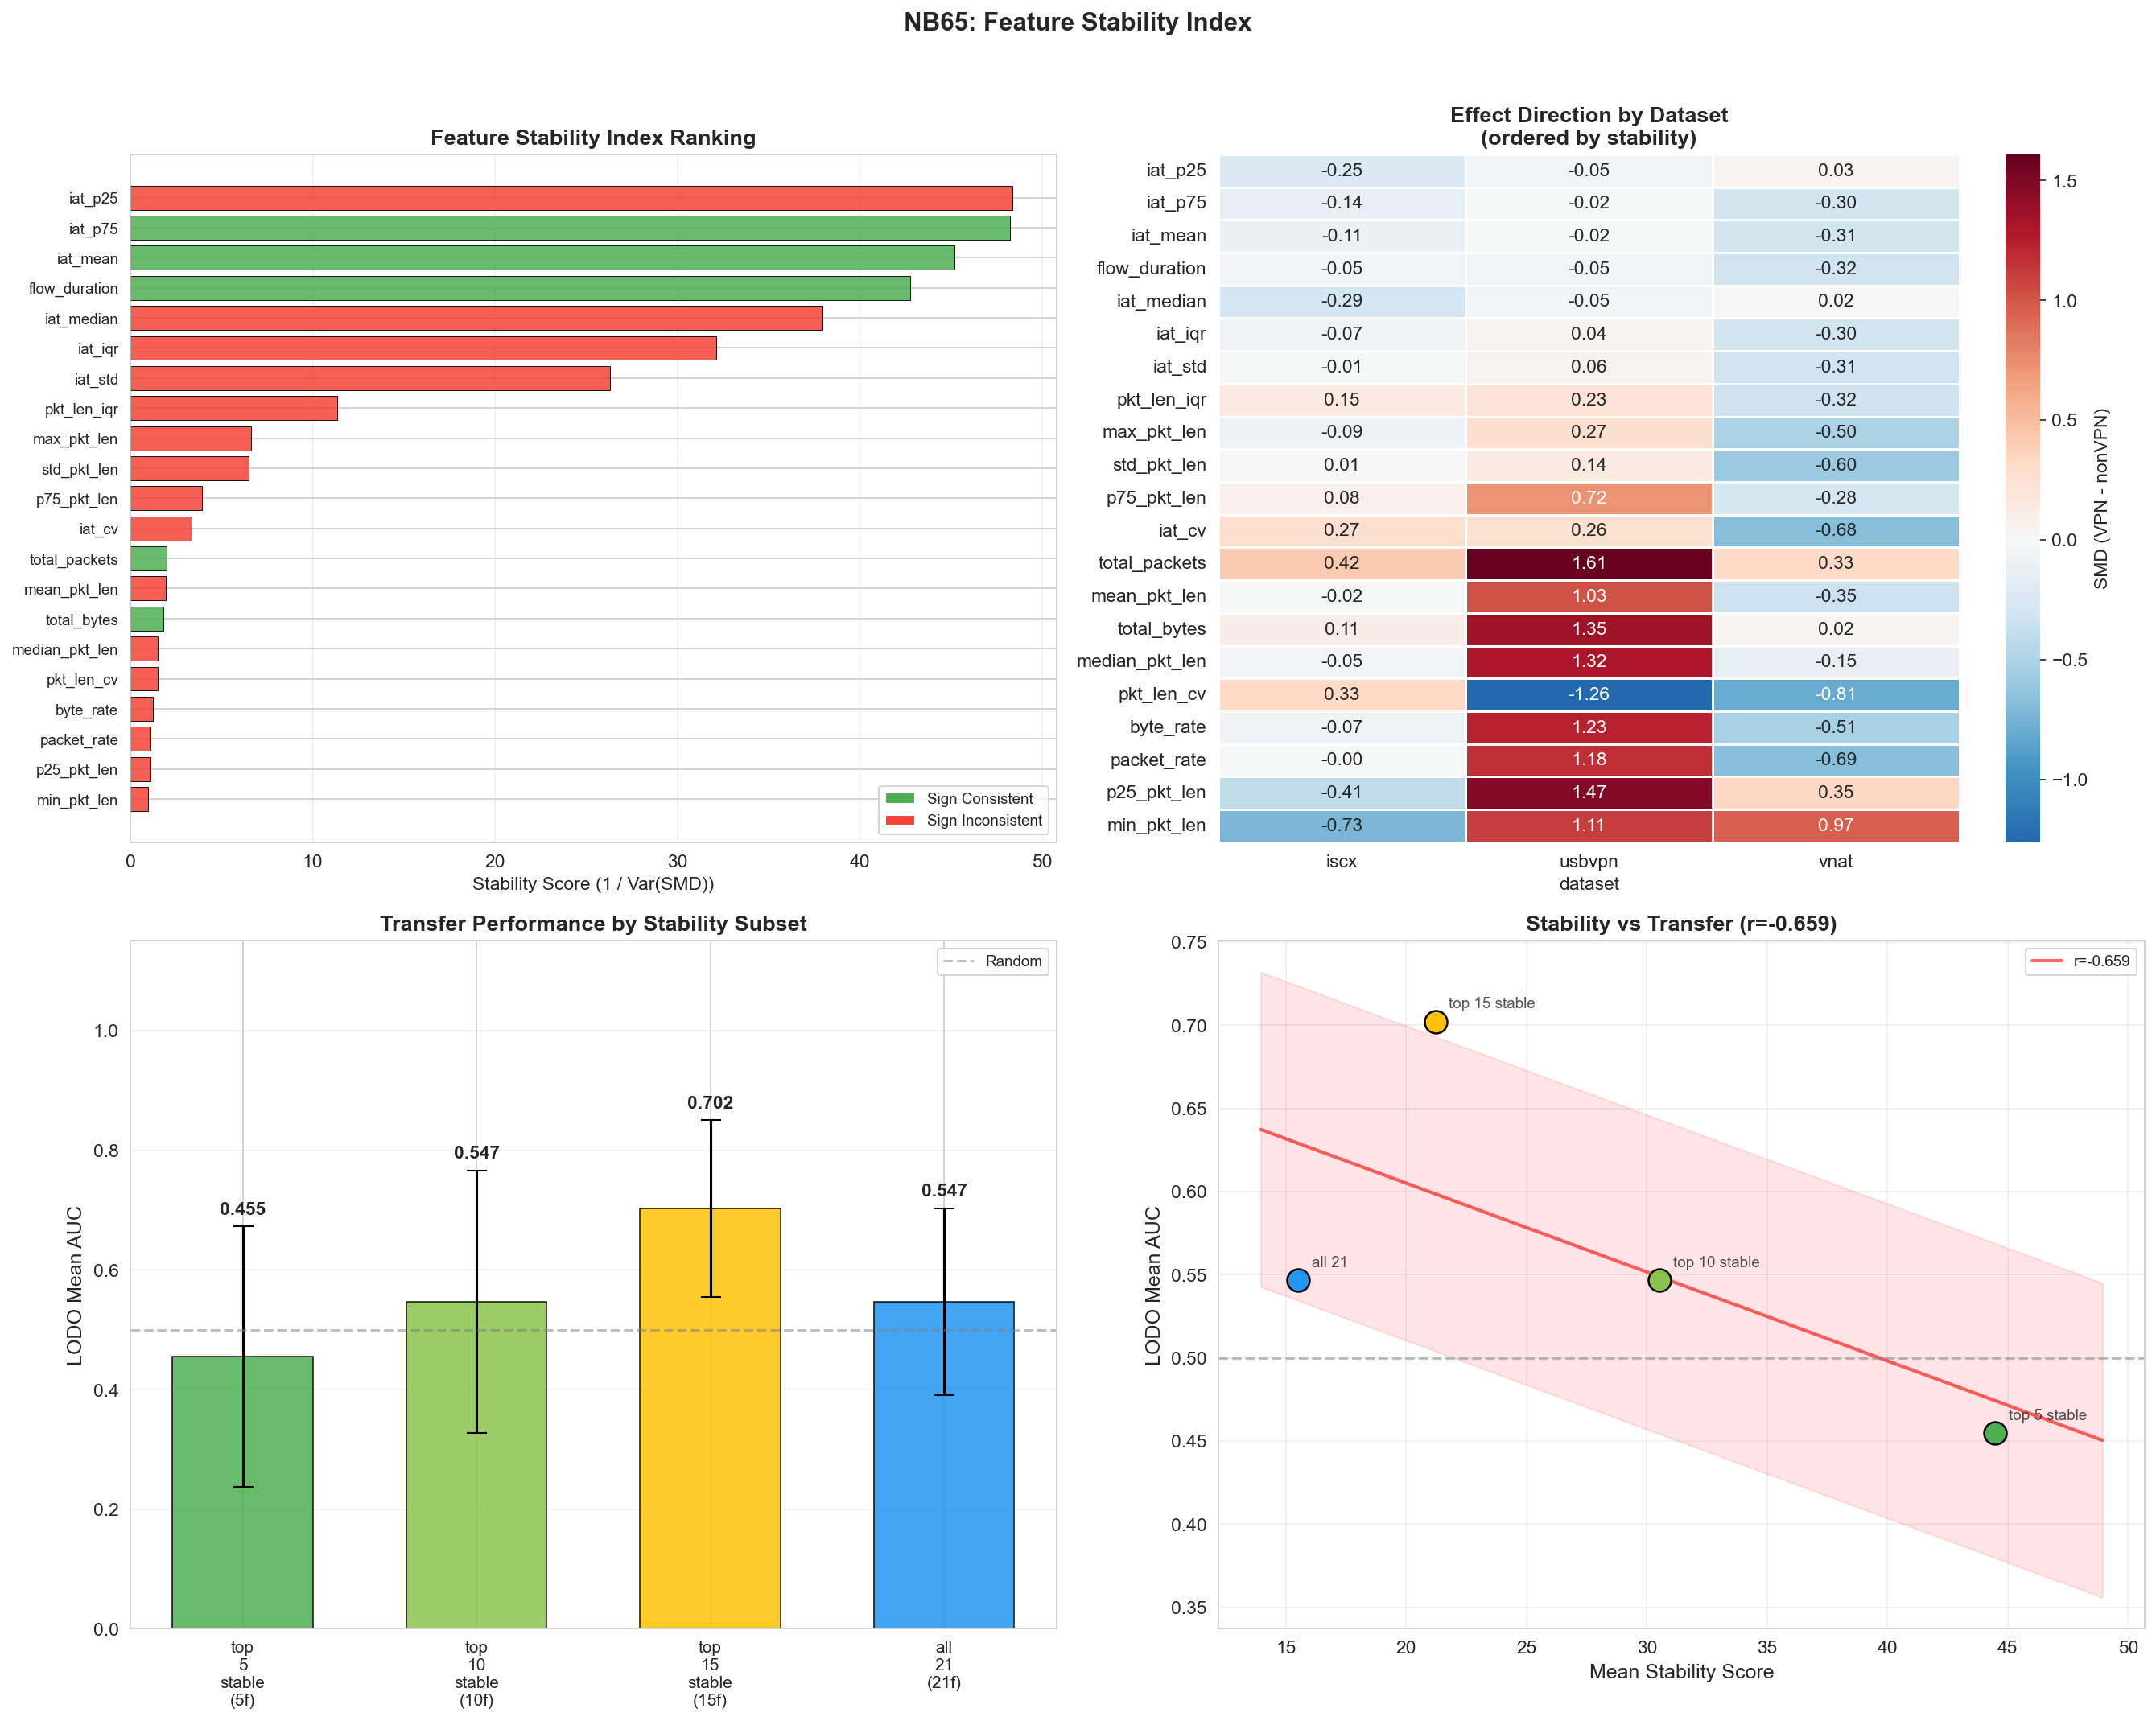


---
### 🖼 {_p.stem.replace("_", " ").title()}

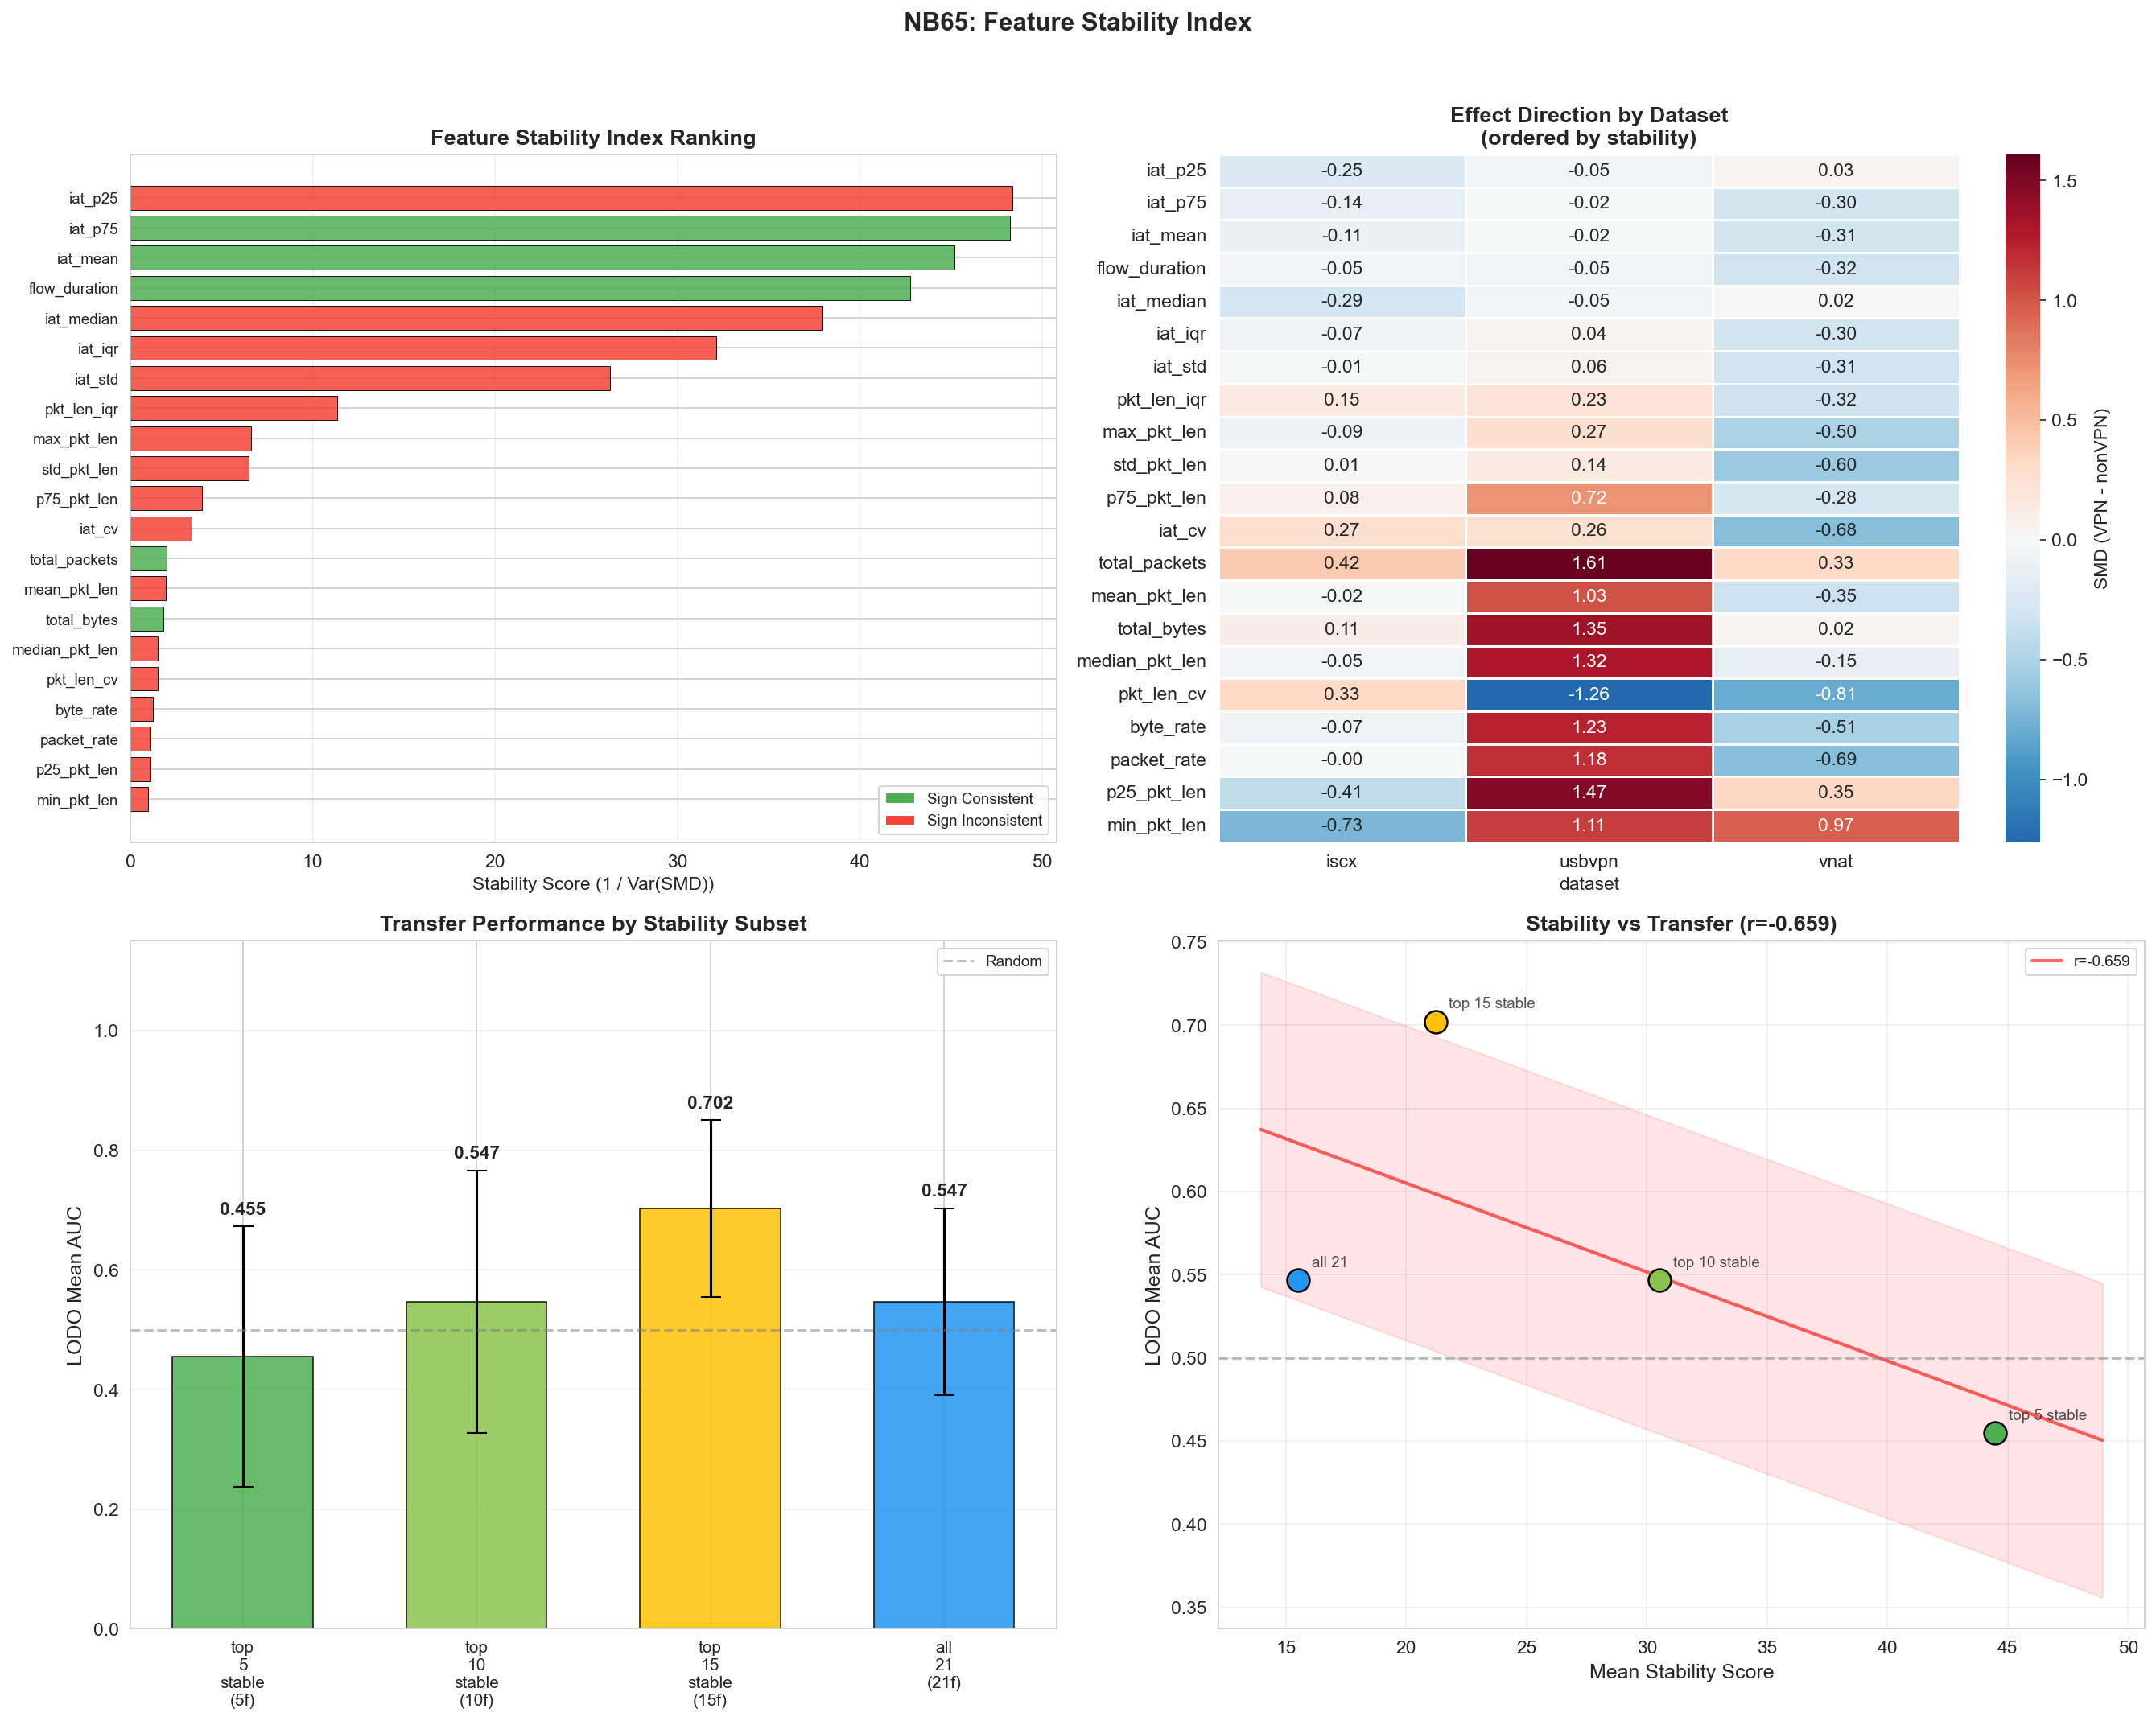


---
# 📋 Result Tables


### {_c.stem.replace("_", " ").title()}

,feature,mean_smd,mean_abs_smd,var_smd,stability_score,sign_consistent,rank
0,iat_p25,-0.0918,0.1105,0.0207,48.3484,False,1
1,iat_p75,-0.1546,0.1546,0.0207,48.2075,True,2
2,iat_mean,-0.1435,0.1435,0.0221,45.1627,True,3
3,flow_duration,-0.1396,0.1396,0.0234,42.7726,True,4
4,iat_median,-0.1092,0.1193,0.0264,37.9315,False,5
5,iat_iqr,-0.1113,0.1386,0.0312,32.1014,False,6
6,iat_std,-0.0884,0.1258,0.0380,26.2869,False,7
7,pkt_len_iqr,0.0163,0.2320,0.0883,11.3247,False,8
8,max_pkt_len,-0.1086,0.2905,0.1514,6.6071,False,9
9,std_pkt_len,-0.1482,0.2491,0.1546,6.4680,False,10


### {_c.stem.replace("_", " ").title()}

,config,n_features,seed,held_out,lodo_auc
0,top_5_stable,5,42,iscx,0.5208
1,top_5_stable,5,42,usbvpn,0.1643
2,top_5_stable,5,42,vnat,0.7172
3,top_5_stable,5,43,iscx,0.5052
4,top_5_stable,5,43,usbvpn,0.1701
5,top_5_stable,5,43,vnat,0.6771
6,top_5_stable,5,44,iscx,0.5117
7,top_5_stable,5,44,usbvpn,0.1595
8,top_5_stable,5,44,vnat,0.6675
9,top_10_stable,10,42,iscx,0.5242


### {_c.stem.replace("_", " ").title()}

,config,n_features,LODO_mean_auc,LODO_std_auc,LODO_min_auc,lodo_iscx_auc,lodo_usbvpn_auc,lodo_vnat_auc
0,top_5_stable,5,0.4549,0.2176,0.1595,0.5126,0.1647,0.6873
1,top_10_stable,10,0.5467,0.2198,0.2769,0.5259,0.2886,0.8254
2,top_15_stable,15,0.7023,0.1481,0.5055,0.5088,0.7303,0.8677
3,all_21,21,0.5468,0.1559,0.3839,0.4730,0.4043,0.7631



---
### 🏁 {_j.stem.replace("_", " ").title()}

```json
{
  "notebook": "NB65",
  "title": "Feature Stability Index",
  "datasets": [
    "iscx",
    "usbvpn",
    "vnat"
  ],
  "n_features": 21,
  "n_seeds": 3,
  "n_estimators": 200,
  "stability_ranking": [
    {
      "feature": "iat_p25",
      "stability_score": 48.34843845033886,
      "var_smd": 0.020683181268465696,
      "mean_smd": -0.09175786004333326,
      "sign_consistent": false
    },
    {
      "feature": "iat_p75",
      "stability_score": 48.20747878665096,
      "var_smd": 0.020743659346941827,
      "mean_smd": -0.15463440425511285,
      "sign_consistent": true
    },
    {
      "feature": "iat_mean",
      "stability_score": 45.16266010577832,
      "var_smd": 0.022142175550138914,
      "mean_smd": -0.14346738918490673,
      "sign_consistent": true
    },
    {
      "feature": "flow_duration",
      "stability_score": 42.77257840514139,
      "var_smd": 0.02337945500507898,
      "mean_smd": -0.13964969757561893,
      "sign_consistent": true
    },
    {
      "feature": "iat_median",
      "stability_score": 37.93150764636898,
      "var_smd": 0.0263632974994773,
      "mean_smd": -0.10922539737475982,
      "sign_consistent": false
    },
    {
      "feature": "iat_iqr",
      "stability_score": 32.10138730365602,
      "var_smd": 0.031151291672439255,
      "mean_smd": -0.11131716069860455,
      "sign_consistent": false
    },
    {
      "feature": "iat_std",
      "stability_score": 26.28686792003066,
      "var_smd": 0.03804179867200225,
      "mean_smd": -0.08841462454461892,
      "sign_consistent": false
    },
    {
      "feature": "pkt_len_iqr",
      "stability_score": 11.32466749583569,
      "var_smd": 0.08830280333802695,
      "mean_smd": 0.016288549713311912,
      "sign_consistent": false
    },
    {
      "feature": "max_pkt_len",
      "stability_score": 6.6071091115147835,
      "var_smd": 0.1513521143742158,
      "mean_smd": -0.10858337488258286,
      "sign_consistent": false
    },
    {
      "feature": "std_pkt_len",
      "stability_score": 6.467978215361469,
      "var_smd": 0.15460780819348074,
      "mean_smd": -0.1482265884574353,
      "sign_consistent": false
    },
    {
      "feature": "p75_pkt_len",
      "stability_score": 3.9079403645162527,
      "var_smd": 0.2558892581884069,
      "mean_smd": 0.17462318986116188,
      "sign_consistent": false
    },
    {
      "feature": "iat_cv",
      "stability_score": 3.3308023178177066,
      "var_smd": 0.30022795449090545,
      "mean_smd": -0.052159320042595526,
      "sign_consistent": false
    },
    {
      "feature": "total_packets",
      "stability_score": 1.9643964119775148,
      "var_smd": 0.509062210793471,
      "mean_smd": 0.7863595524645722,
      "sign_consistent": true
    },
    {
      "feature": "mean_pkt_len",
      "stability_score": 1.9409203508062265,
      "var_smd": 0.5152194834658789,
      "mean_smd": 0.2193433246408146,
      "sign_consistent": false
    },
    {
      "feature": "total_bytes",
      "stabi
```


✅ NB65 gallery complete.


In [1]:
# ── Results Gallery: NB65 — Display all figures and tables ────────
import json, warnings
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

warnings.filterwarnings('ignore')

# Resolve output directory
if 'OUT' not in dir() and 'OUT_DIR' not in dir():
    ROOT = Path.cwd()
    if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
        ROOT = ROOT.parent
    _gallery_dir = ROOT / "artifacts" / "thesis_finalization" / "nb65_feature_stability_index"
else:
    _gallery_dir = Path(str(OUT)) if 'OUT' in dir() else Path(str(OUT_DIR))

# Also check for a figures/ subdirectory
_fig_dir = _gallery_dir / 'figures'

# Collect all PNGs
_pngs = sorted(_gallery_dir.glob('*.png'))
if _fig_dir.exists():
    _pngs += sorted(_fig_dir.glob('*.png'))
_pngs = sorted(set(_pngs), key=lambda p: p.name)

# Collect all CSVs
_csvs = sorted(_gallery_dir.glob('*.csv'))

display(Markdown(f'# \U0001f4ca NB65 Results Gallery — {len(_pngs)} figures, {len(_csvs)} tables'))

# ── Display all PNG figures ──
if _pngs:
    for _p in _pngs:
        display(Markdown(f'\n---\n### \U0001f5bc {{_p.stem.replace("_", " ").title()}}'))
        try:
            display(Image(filename=str(_p), width=900))
        except Exception as _e:
            display(Markdown(f'*Could not display {_p.name}: {_e}*'))
else:
    display(Markdown('*No PNG files found in gallery directory. Run notebook cells first.*'))

# ── Display all CSV tables ──
if _csvs:
    display(Markdown('\n---\n# \U0001f4cb Result Tables\n'))
    for _c in _csvs:
        try:
            _tbl = pd.read_csv(_c)
            display(Markdown(f'### {{_c.stem.replace("_", " ").title()}}'))
            for _col in _tbl.select_dtypes(include="float").columns:
                _tbl[_col] = _tbl[_col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
            display(_tbl)
        except Exception as _e:
            display(Markdown(f'*Could not load {_c.name}: {_e}*'))

# ── Display JSON verdict if present ──
_jsons = sorted(_gallery_dir.glob('*verdict*.json')) + sorted(_gallery_dir.glob('*summary*.json'))
_jsons = sorted(set(_jsons), key=lambda p: p.name)
for _j in _jsons[:2]:
    try:
        _data = json.loads(_j.read_text(encoding='utf-8'))
        display(Markdown(f'\n---\n### \U0001f3c1 {{_j.stem.replace("_", " ").title()}}'))
        display(Markdown(f'```json\n{json.dumps(_data, indent=2, default=str)[:3000]}\n```'))
    except Exception:
        pass

print('\n\u2705 NB65 gallery complete.')
